# Data Mining - A.A. 2025/2026
## Progetto Gruppo G3.3
### Membri:
- Masala Gabriele: 60/61/66245 (60/99/00004)
- Mantega Gabriele: 60/61/66251 (60/99/00006)
- Aresu Matteo: 60/99/00014

# 1 - Analisi del Dataset

In [98]:
# Dichiarazione Import
import pandas as pd
import numpy as np
import os
from sklearn import datasets
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction import text as sktext

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt
from matplotlib import patches as mpatches

In [180]:
# Direttive di Pandas per avere un output più leggibile
pd.set_option('display.max_colwidth', 100)

# Fetch del dataset 20newsgroups
categories = ['rec.autos','rec.sport.baseball', 'sci.electronics', 'sci.med' , 'sci.space']
train_dataset = datasets.fetch_20newsgroups(subset='train', categories=categories)
test_dataset = datasets.fetch_20newsgroups(subset='test', categories=categories)
target_names = train_dataset.target_names

# Otteniamo i dataframe con i dati e i target per ciascun dataset (train e test)
X_train = pd.DataFrame(train_dataset.data).rename(columns={0: 'raw_text'})
y_train = train_dataset.target
X_test = pd.DataFrame(test_dataset.data).rename(columns={0: 'raw_text'})
y_test = test_dataset.target

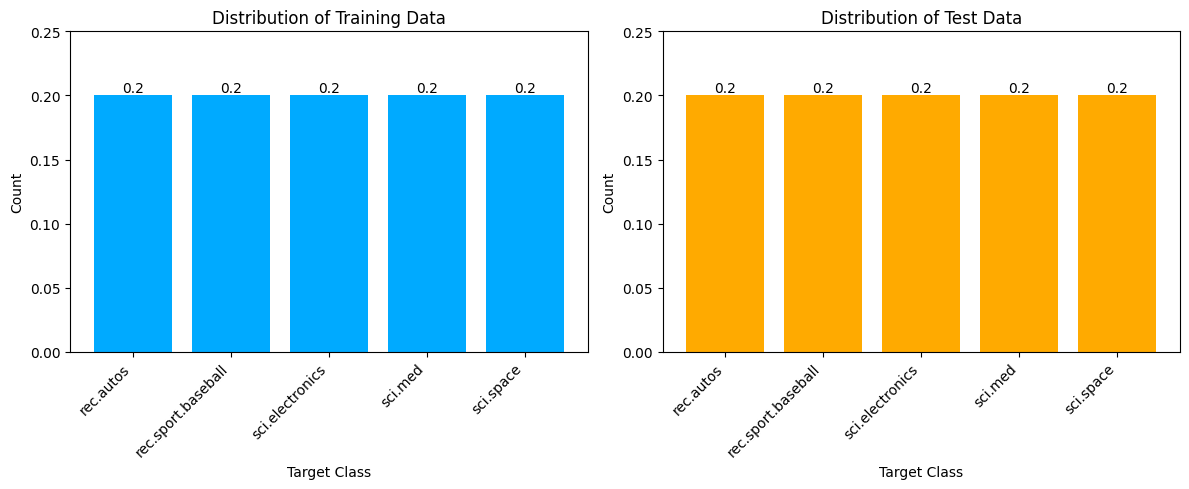

In [181]:
train_count = pd.DataFrame({"data": train_dataset.data, "target": train_dataset.target}).groupby("target").count()
test_count = pd.DataFrame({"data": test_dataset.data, "target": test_dataset.target}).groupby("target").count()
train_distr = (train_count/len(train_dataset.data)).data.round(2)
test_distr = (test_count/len(test_dataset.data)).data.round(2)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
bar = plt.bar(target_names, test_distr, color='#00AAFF')
plt.bar_label(bar)
plt.title('Distribution of Training Data')
plt.xlabel('Target Class')
plt.ylabel('Count')
plt.ylim([0,0.25])
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 2, 2)
bar = plt.bar(target_names, test_distr, color='#FFAA00')
plt.bar_label(bar)
plt.title('Distribution of Test Data')
plt.xlabel('Target Class')
plt.ylabel('Count')
plt.ylim([0,0.25])
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

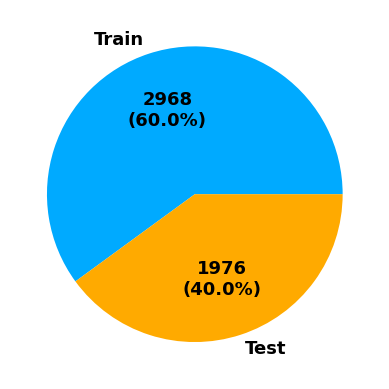

In [182]:
total_distr = [train_count.sum().data, test_count.sum().data]
autopct_func = lambda p: f'{int(p/100*sum(total_distr))}\n({p:.1f}%)'

plt.figure()
plt.pie(total_distr, labels=['Train', 'Test'], autopct=autopct_func, colors=['#00AAFF', '#FFAA00'],
textprops={'weight': 'bold', 'fontsize': 13, 'color': 'black'})
plt.show()

# 2 - Preprocessing

## 2.1 Tf-Idf

In [183]:
# Utilizzo la classe TfidfVectorizer per convertire i record testuali in record numerici
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=100)
# tfidf_train = tfidf_vectorizer.fit_transform(X_train['raw_text'])
# tfidf_test = tfidf_vectorizer.transform(X_test['raw_text'])

tfidf_train = tfidf_vectorizer.fit_transform(X_train['raw_text'])
tfidf_test = tfidf_vectorizer.transform(X_test['raw_text'])


## 2.2 GloVe

In [184]:
# FUNZIONI DI PREPROCESSING PER GLOVE

# Load GloVe embeddings into a dictionary (presa da spot-intelligence)
def load_embeddings(file_path):
    embeddings = {}
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File {file_path} not found. Please check the path and try again.")
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            vector = np.asarray(values[1:], dtype='float32')
            embeddings[word] = vector
    return embeddings

# ---------------------------------------

# esegue: lowercase, tokenizzazione, rimozione della punteggiatura e delle stopword
def preprocess_text(text):
    # Converti il testo in minuscolo
    text = text.lower()
    
    # Rimuovi la punteggiatura
    text = ''.join(char for char in text if char.isalnum() or char.isspace())
    
    # Tokenizza il testo
    tokens = text.split()
    
    # Rimuovi le stopword (opzionale, puoi usare una lista di stopword)
    stopwords = sktext.ENGLISH_STOP_WORDS # stopwords di sklearn
    tokens = [tkn for tkn in tokens if tkn not in stopwords]
    
    return tokens

# ---------------------------------------

# Calcola l'embedding del documento come media degli embedding delle parole
def get_document_embedding(tokens, glove_embeddings):
    # Ottieni gli embedding per ogni parola nel documento
    word_embeddings = [glove_embeddings[token] for token in tokens if token in glove_embeddings.keys()] # Verifica se la parola ha un embedding disponibile
    
    # Calcola la media degli embedding per ottenere l'embedding del documento
    if word_embeddings:
        document_embedding = np.mean(word_embeddings, axis=0) 
    else:
        document_embedding = np.zeros(len(glove_embeddings[list(glove_embeddings.keys())[0]]))  # Se nessuna parola ha embedding, restituisci un vettore di zeri
    
    return document_embedding

# ---------------------------------------

# caricamento degli embeddings GloVe
glove_embeddings_path = 'glove.6B.100d.txt'  
glove_embeddings = load_embeddings(glove_embeddings_path)

# Preprocessamento del testo e calcolo degli embedding dei documenti
rows_train = []
for text in X_train['raw_text']:
    tokens = preprocess_text(text)
    rows_train.append(get_document_embedding(tokens, glove_embeddings))

rows_test = []
for text in X_test['raw_text']:
    tokens = preprocess_text(text)
    rows_test.append(get_document_embedding(tokens, glove_embeddings))

# Creazione di un DataFrame per visualizzare i risultati
glove_train = np.array(rows_train)
glove_test = np.array(rows_test)


# 3. Classificazione

In [185]:
# Inizializzazione classificatori
classifiers = {
    'Decision Tree': DecisionTreeClassifier(max_depth=8, min_samples_split=0.01, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=15, metric='cosine', weights='distance'),
    'MLP': MLPClassifier(hidden_layer_sizes=(100, 64), max_iter=300, early_stopping=True, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, learning_rate=0.5, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, learning_rate=0.5, random_state=42)
}

# Dati di training e test, distinti per tipo di rappresentazione (TF-IDF e GloVe)
data = {
    'TF-IDF': {"train": tfidf_train, "test": tfidf_test},
    'GloVe': {"train": glove_train, "test": glove_test}
}

In [ ]:
# Alleniamo e valutiamo tutti i modelli

results = {}
for repr in data.keys():

    # caricamento dei dati per training e testing
    print(f"Now testing on {repr}") # stampa la rappresentazione utilizzata
    X_train = data[repr]["train"]
    X_test = data[repr]["test"]

    # ciclo di training dei classificatori
    performances = []
    for clf_name, clf in classifiers.items():
        import time
        # training del modello
        print(f" Training {clf_name}...", end = "") # stampa il nome del modello
        start_time = time.time() # inizio del timer
        clf.fit(X_train, y_train)
        end_time = time.time() # fine del timer
        y_pred = clf.predict(X_test)
        
        # valutazione del modello e salvataggio delle performance
        performances.append({
            'Model': clf_name,
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred, average='macro', zero_division=0),
            'Recall': recall_score(y_test, y_pred, average='macro', zero_division=0),
            'F1': f1_score(y_test, y_pred, average='macro', zero_division=0),
            'ConfMatrix': confusion_matrix(y_test, y_pred)
        })
        print(f"OK (elapsed time: {end_time - start_time:.2f} seconds)")
    print()

    results[repr] = performances

Now testing on TF-IDF
 Training Decision Tree...OK (elapsed time: 0.13 seconds)
 Training KNN...OK (elapsed time: 0.01 seconds)
 Training MLP...OK (elapsed time: 5.55 seconds)
 Training Random Forest...OK (elapsed time: 8.97 seconds)
 Training AdaBoost...OK (elapsed time: 3.00 seconds)
 Training XGBoost...OK (elapsed time: 30.04 seconds)

Now testing on GloVe
 Training Decision Tree...OK (elapsed time: 0.56 seconds)
 Training KNN...OK (elapsed time: 0.00 seconds)
 Training MLP...OK (elapsed time: 8.10 seconds)
 Training Random Forest...OK (elapsed time: 16.23 seconds)
 Training AdaBoost...OK (elapsed time: 9.68 seconds)
 Training XGBoost...OK (elapsed time: 12.31 seconds)



In [187]:
# Mostro i risultati
for repr_name, performances in results.items():
    print("\n" + "="*54)
    print(f"Classification {repr_name} Summary")
    print("="*54)
    print((pd.DataFrame(performances).drop(columns=['ConfMatrix'])).set_index('Model'))


Classification TF-IDF Summary
               Accuracy  Precision    Recall        F1
Model                                                 
Decision Tree  0.556174   0.692627  0.555690  0.577371
KNN            0.571862   0.569368  0.571793  0.569623
MLP            0.627024   0.633243  0.626926  0.628704
Random Forest  0.641700   0.658318  0.641656  0.647513
AdaBoost       0.566296   0.682459  0.566613  0.584045
XGBoost        0.627530   0.637206  0.627440  0.631304

Classification GloVe Summary
               Accuracy  Precision    Recall        F1
Model                                                 
Decision Tree  0.661943   0.663076  0.661640  0.661886
KNN            0.882591   0.884540  0.882501  0.882877
MLP            0.892713   0.893144  0.892539  0.891950
Random Forest  0.873988   0.874627  0.873879  0.874128
AdaBoost       0.804150   0.808830  0.804012  0.805615
XGBoost        0.879555   0.880382  0.879478  0.879764


<Figure size 640x480 with 0 Axes>

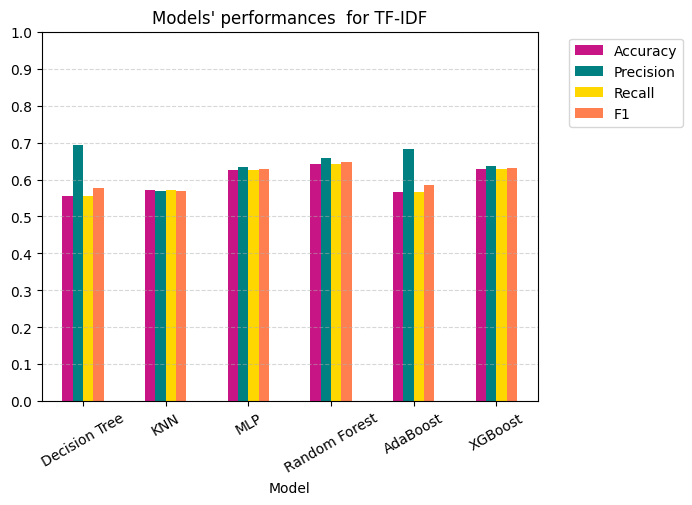

<Figure size 640x480 with 0 Axes>

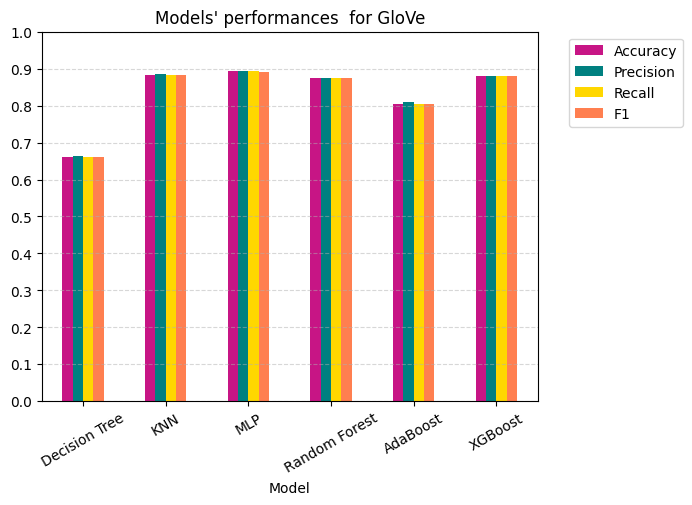

In [188]:
metrics_colors = [
    'mediumvioletred', 
    'teal', 
    'gold', 
    'coral'
]

for repr_name, performances in results.items():
    plt.figure()
    
    performances_df = pd.DataFrame(performances).set_index('Model')
    performances_df.plot.bar(color=metrics_colors).legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.xticks(rotation=30)
    plt.ylim([0,1])
    plt.yticks(np.arange(0,1.1,step=0.1))
    plt.tick_params('x')
    plt.grid(True, axis='y', linestyle='--', alpha=0.5)
    plt.title(f'Models\' performances  for {repr_name}')
    plt.show()

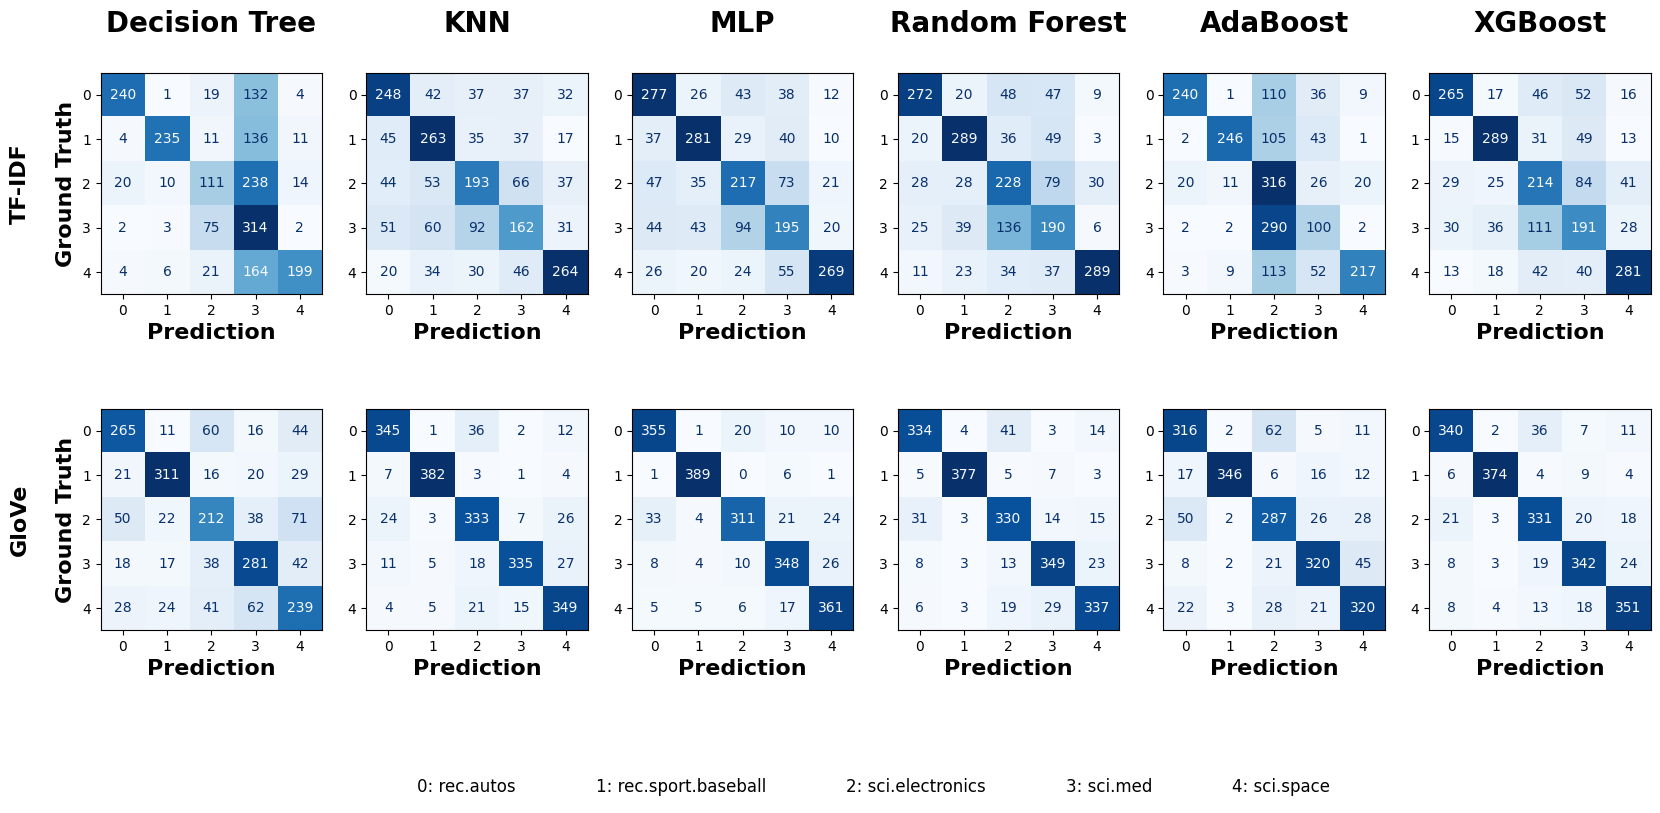

In [189]:
confusion_matrices = [[model['ConfMatrix'] for model in repr] for repr in results.values()]
y_labels = results.keys()
x_labels = classifiers.keys()

n_rows = len(results)
n_cols = len(classifiers)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(20, 8))

for i in range(n_rows):
    for j in range(n_cols):
        ax = axes[i,j]
        cm = confusion_matrices[i][j]
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(ax=ax, cmap='Blues', colorbar=False)

for i, label in enumerate(y_labels):
    for ax in axes[i, :]:
        ax.set_ylabel('')
    axes[i, 0].set_ylabel(label+"\n\nGround Truth", fontsize=16, fontweight='bold')

for i, label in enumerate(x_labels):
    for ax in axes[:, i]:
        ax.set_xlabel('Prediction', fontsize=16, fontweight='bold')
    axes[0, i].set_title(label+'\n', fontsize=20, fontweight='bold')

legend_handles = [
    mpatches.Patch(color="none", label=f"{num}: {name}")
    for num, name in enumerate(target_names)
]

fig.legend(
    handles=legend_handles, 
    loc='center', 
    bbox_to_anchor=(0.5, -0.05), 
    ncol=len(target_names),
    fontsize=12,
    frameon=False
)
plt.show()

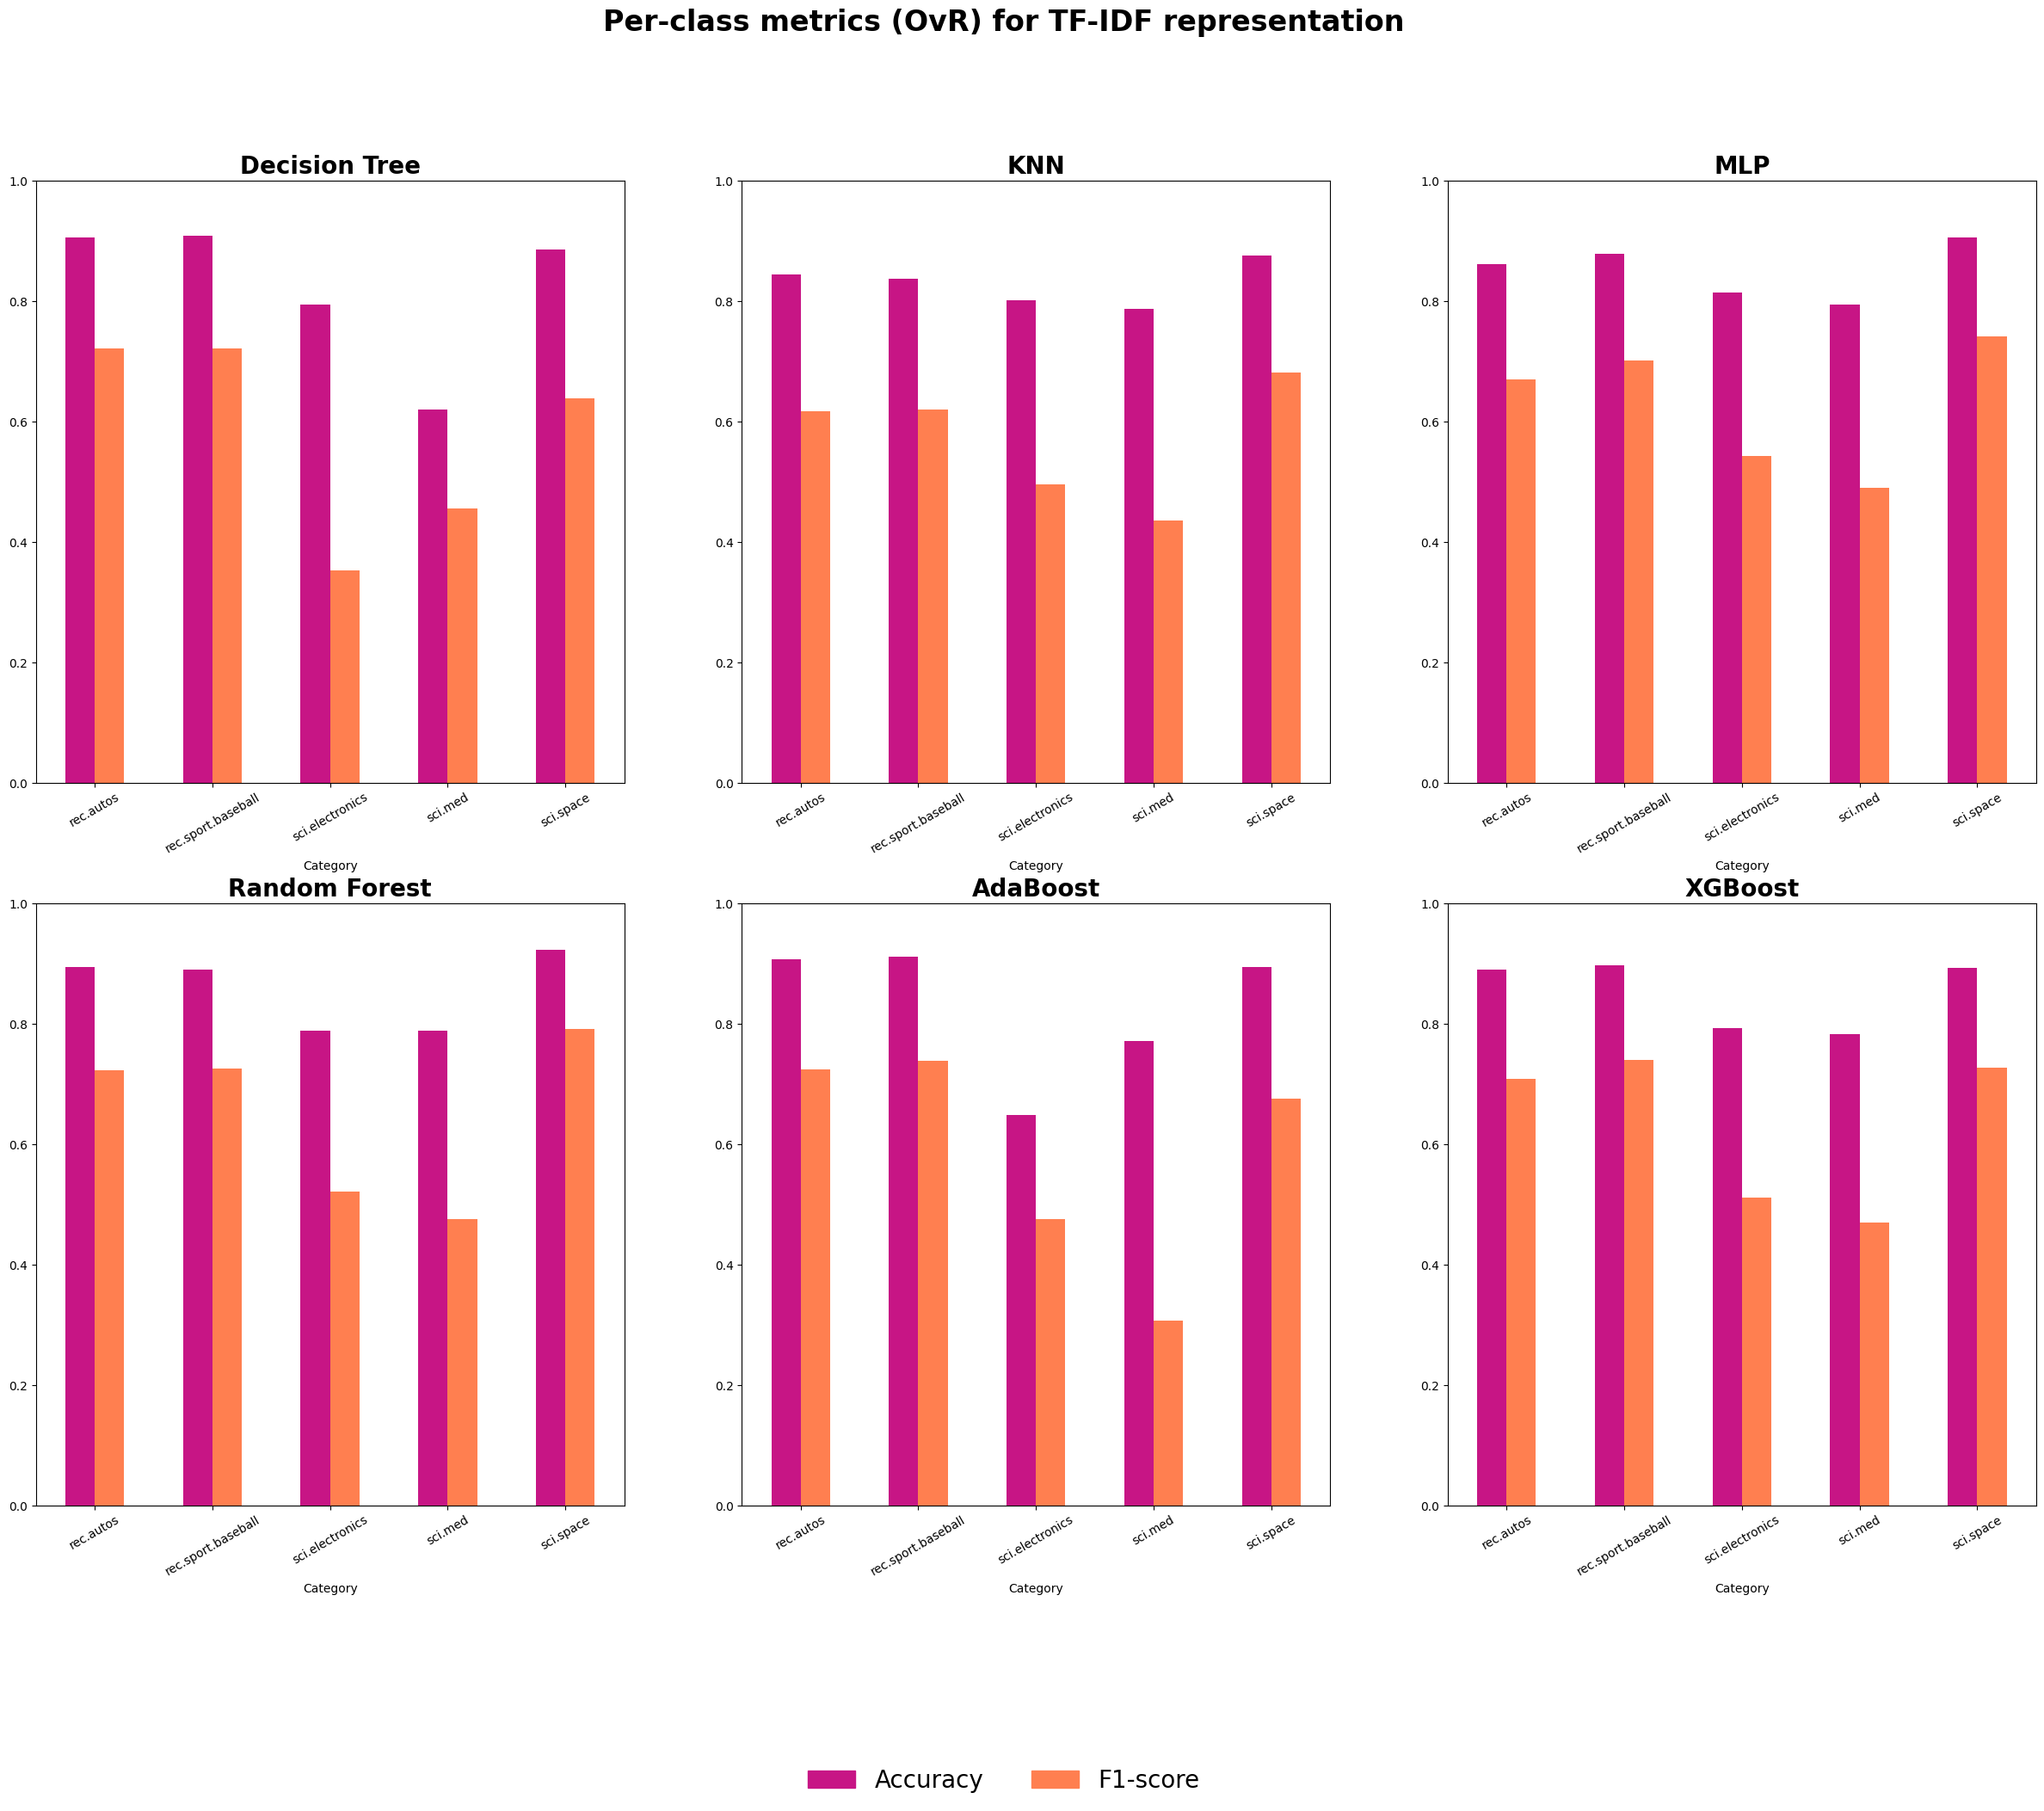

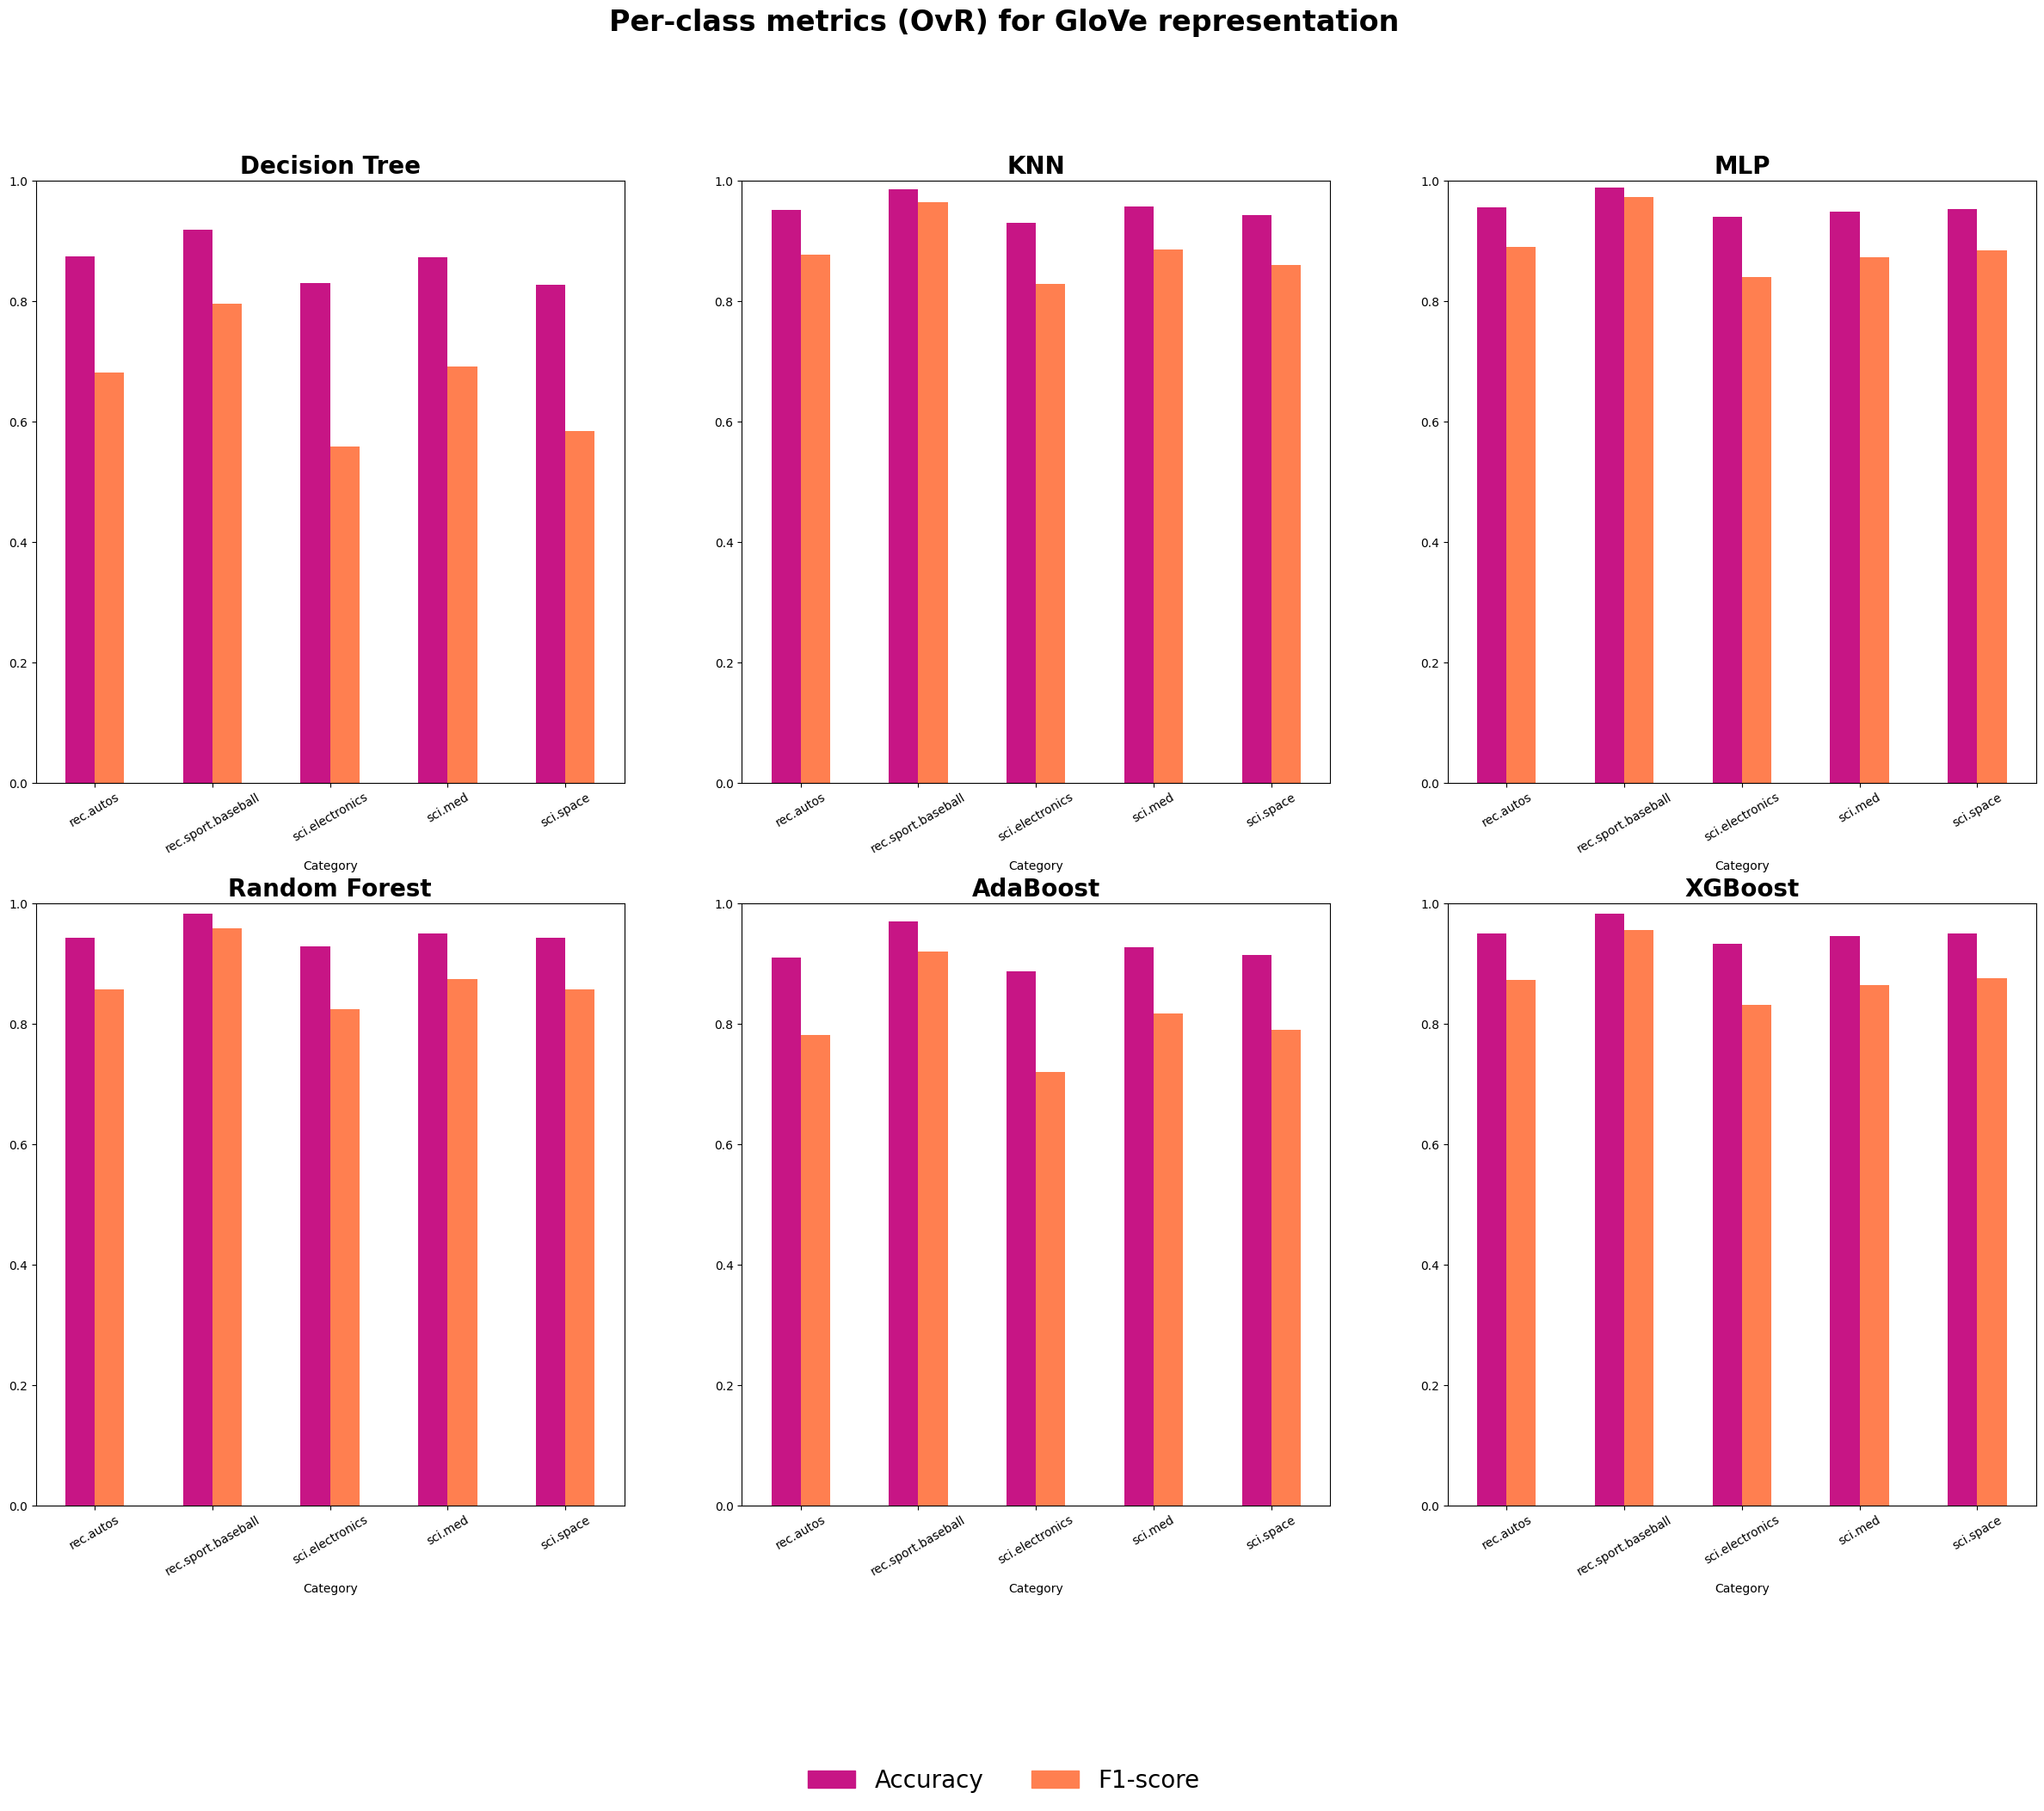

In [272]:
metrics_colors = [
    'mediumvioletred', 
    'coral'
]
metrics = [
    'Accuracy',
    'F1-score'
]

for j,repr in enumerate(results.keys()):
    fig, axes = plt.subplots(nrows=2,ncols=3,figsize=(30,20))
    fig.suptitle(f'Per-class metrics (OvR) for {repr} representation', fontsize=24, fontweight='bold')
    axes = axes.flatten()

    for k,clf_name in enumerate(classifiers.keys()):
        cm= [{model['Model']:model['ConfMatrix'] for model in repr} for repr in results.values()][j][clf_name]

        def class_metrics(conf_matrix, class_id, metric):
            tp = conf_matrix[class_id, class_id]
            fp = np.sum(conf_matrix, axis=0)[class_id] - tp
            fn = np.sum(conf_matrix, axis=1)[class_id] - tp
            tn = np.sum(conf_matrix) -tp -fp -fn

            return metric(tp,fp,fn,tn)

        accuracy = lambda tp,fp,fn,tn: (tp+tn)/(tp+fp+fn+tn)
        recall = lambda tp,fp,fn,tn: tp/(tp+fn)
        precision = lambda tp,fp,fn,tn: tp/(tp+fp)
        f1_score = lambda tp,fp,fn,tn: 2*(recall(tp,fp,fn,tn)*precision(tp,fp,fn,tn))/(recall(tp,fp,fn,tn)+precision(tp,fp,fn,tn))

        pd.DataFrame({'Category' : [target for target in target_names],
        'Accuracy' : [class_metrics(cm,i,accuracy) for i in range(len(target_names))],
        'F1 score' : [class_metrics(cm,i,f1_score) for i in range(len(target_names))]}).set_index('Category').plot.bar(color=metrics_colors, legend=False, ax=axes[k])
        axes[k].set_title(clf_name, fontsize=20, fontweight='bold')
        axes[k].set_ylim([0,1])
        axes[k].tick_params(axis='x', labelrotation=30)


    legend_handles = [mpatches.Patch(color=metrics_colors[i], label=metrics[i]) for i in range(len(metrics))
]
    fig.legend(
        handles=legend_handles, 
        loc='center', 
        bbox_to_anchor=(0.5, -0.05), 
        ncol=len(target_names),
        fontsize=20,
        frameon=False
    )

    plt.show()